# Sentinel-2 L2A extraction with AerEO

This chapter walks through a complete AerEO extraction pipeline for **Sentinel-2 L2A** imagery.

AerEO is built around the `ExtractionJob`. A job declaratively combines a **search** provider, a **reader**, optional **preprocess/reproject/postprocess** steps, a **writer**, and a **grid** definition that splits the area of interest (AOI) into independent tasks. By keeping all of this in a YAML config, the same job can be reproduced from a notebook, the command line, or an AWS Lambda handler.


## Environment setup

The first cell installs AerEO and any required plugins. If you are reading the rendered book or running on Binder, where the environment is already prepared, `pip` will report that the requirements are satisfied and skip the download.


In [ ]:
# Install AerEO and any required plugins for this notebook (Google Colab)
!pip install -q "aereo[viz]" # if using planetarey-computer version: aereo[viz,pc] 

## Config files used in this chapter

The next cell downloads two files:

1. **`job_sentinel2.yaml`** — the AerEO job configuration.
2. **`chocon.geojson`** — the AOI over Argentina’s Chocón region.

Keeping configuration outside the notebook makes the pipeline reusable and version-controllable. Here is the full YAML we are loading:

```yaml
# Common vars reused in the config
target_bands: [red, nir]
aoi_path: config/aoi/chocon.geojson

name: sentinel2_sample
grid_dist: 10_000
grid_cells_margin: 10
target_aoi: ${aoi_path}
output_uri: /tmp/aereo_extraction
overwrite: false

search:
  _target_: aereo.builtins.search_stac
  _partial_: true
  stac_api_url: "https://earth-search.aws.element84.com/v1"
  collections:
    sentinel-2-l2a: ${target_bands}
  intersects: ${aoi_path}
  start_datetime: "2024-01-01T00:00:00Z"
  end_datetime: "2024-01-10T23:59:59Z"

read:
  _partial_: true
  _target_: aereo.builtins.read_odc_stac
write:
  _target_: aereo.builtins.write.write_geotiff
```

Key fields:

- **`target_aoi`** — path to the AOI GeoJSON.
- **`grid_dist`** — spacing of the MajorTOM grid used to split the AOI into cells (10 km here).
- **`search.collections`** — STAC collection and bands to retrieve.
- **`read`** and **`write`** — plugin callables that load assets and save GeoTIFFs.


In [ ]:
# Download config files and AOIs from the GitHub repository so this
# notebook can run outside the repo (e.g. Google Colab).
import os
import urllib.request

GITHUB_RAW = "https://raw.githubusercontent.com/frandorr/aereo/main"

os.makedirs("config/aoi", exist_ok=True)

# Config files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/job_sentinel2.yaml",  # use job_sentinel2-pc.yaml for planetary-computer version
    "config/job_sentinel2.yaml",
)

# AOI files
urllib.request.urlretrieve(
    f"{GITHUB_RAW}/examples/config/aoi/chocon.geojson",
    "config/aoi/chocon.geojson",
)

## Loading the job

`ExtractionJob.load_from_config()` parses the YAML with [Hydra](https://hydra.cc/), resolves every `_target_` callable, and validates the resulting `ExtractionJob`. The `config_name` argument is the YAML filename without extension, and `config_dir` is the folder that contains it.

A job is a declarative bundle of pipeline steps. Once loaded, the same job can be searched, can have tasks built from it, and can be executed.


In [1]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob

# Load the job from the Hydra config package.
job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_sentinel2",
)

## Search and task building

`job.search()` calls the configured search provider and returns a GeoDataFrame of matched assets. This is a separate step from execution: it only discovers what data is available, without reading or writing anything.

`job.build_tasks(assets)` turns those assets into a list of `ExtractionTask` objects. Each task groups the assets needed for one grid cell and time slice, so the work can be parallelised later.


In [2]:
assets = job.search()  # Use the search method from the job object to get the assets.
tasks = job.build_tasks(assets)
len(tasks)

2026-07-08 14:47:05 [info     ] search_called                  provider=search_stac
2026-07-08 14:47:07 [info     ] build_tasks_start              assets=16 builder=build_grouped_tasks


8

## The executor

AerEO separates *what* to run (the tasks) from *how* to run them. `LocalExecutor` runs tasks on the local machine. The `workers` argument controls parallelism, and `use_threads=True` uses a threading backend, which is a good default for I/O-bound COG readers.


In [3]:
# now we create an Executor, in this case a LocalExecutor to run
# each ExtractionTask using Threads
local_exec = LocalExecutor(workers=-1, use_threads=True, cache=TaskResultCache())

## Running the extraction

`job.execute(tasks, executor=...)` hands the prepared tasks to the executor. The executor runs each task independently; inside every task AerEO performs the pipeline:

```text
read -> preprocess -> reproject -> postprocess -> write
```

The returned object is a GeoDataFrame of **artifacts** — one row per output GeoTIFF with its metadata, CRS, and footprint.


In [4]:
# Extract!
print("Extracting...")
artifacts = job.execute(tasks, executor=local_exec)
print(f"✓ Extracted {len(artifacts)} artifacts")

Extracting...
2026-07-08 14:47:07 [info     ] execute_start                  executor=LocalExecutor task_count=8
✓ Extracted 56 artifacts


## Visualizing results

`plot_artifact_patches` renders the extracted patches over the AOI. The `stretch="percentile"` option improves contrast by clipping to a percentile range.


(<Figure size 2000x1495.93 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


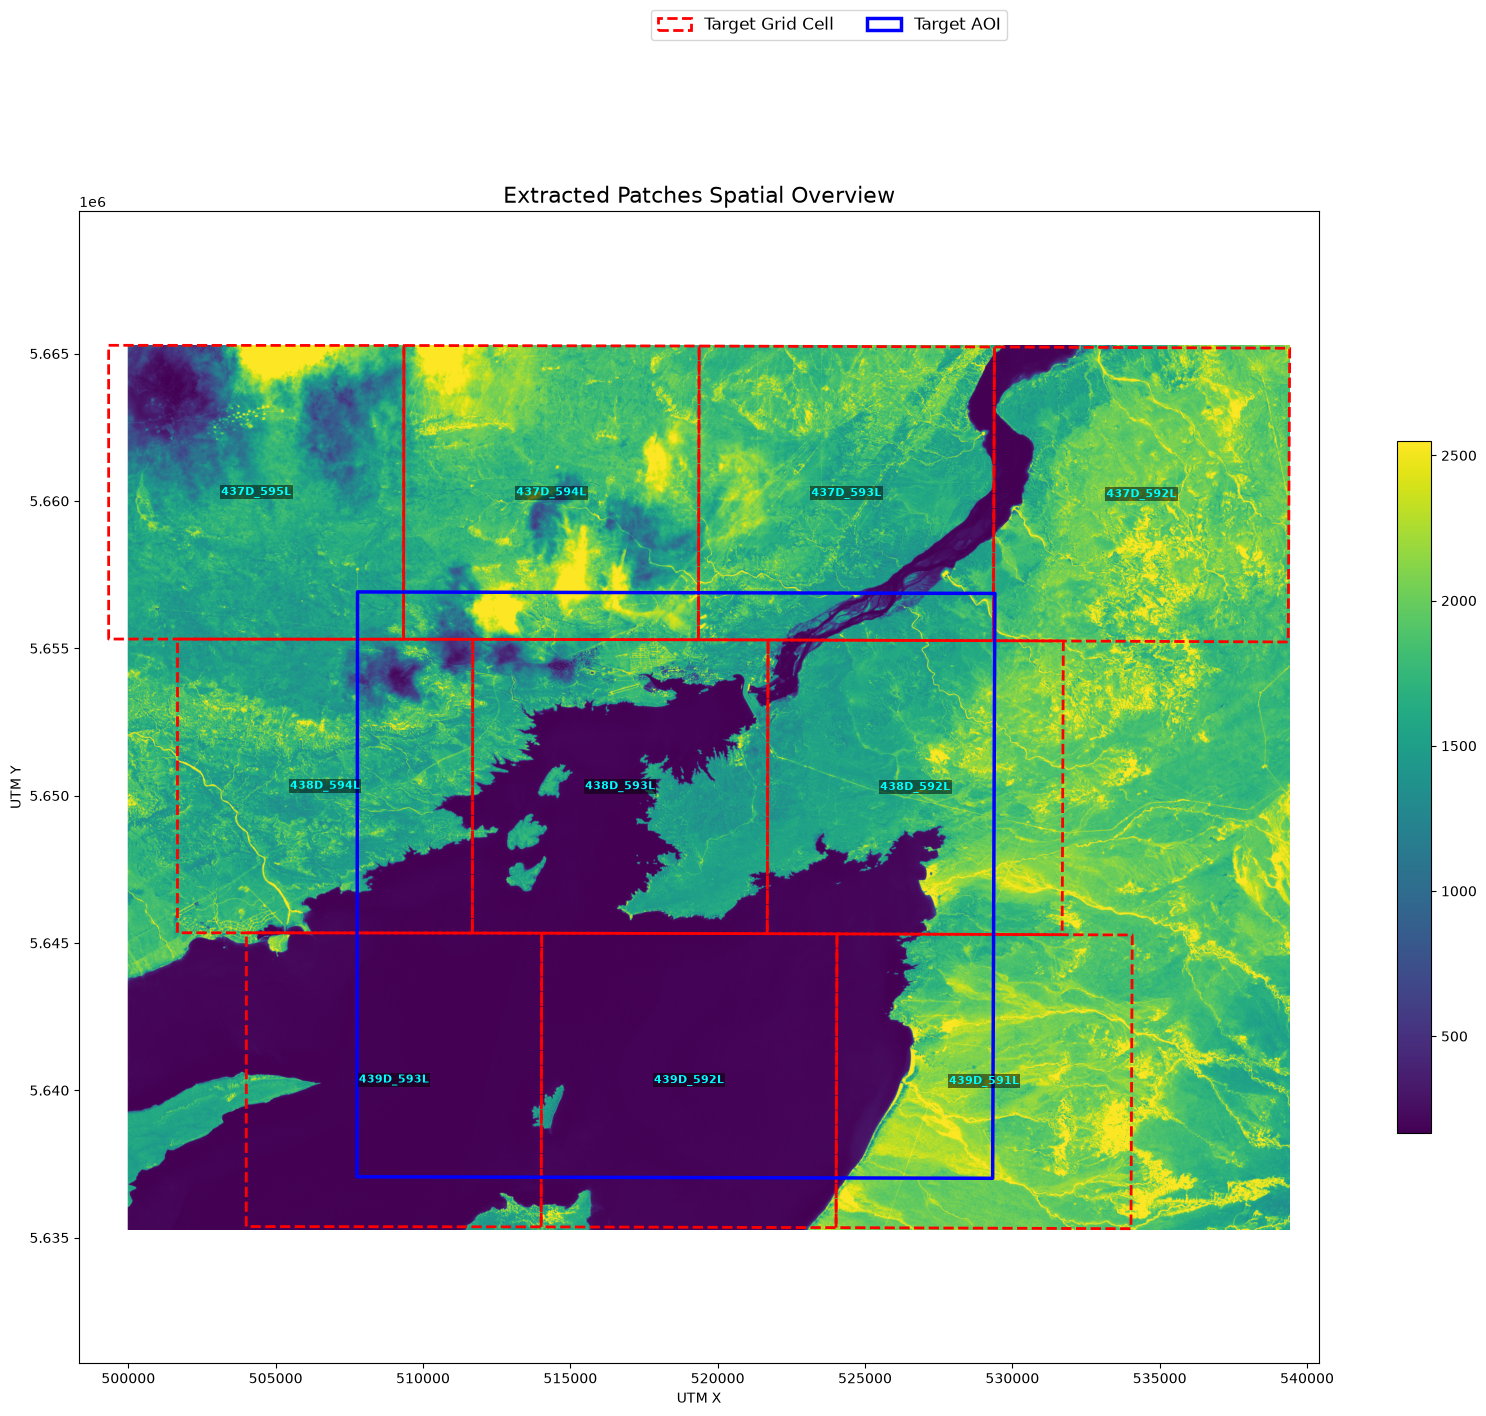

In [5]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(
    artifacts,
    ds_factor=1,
    cmap="viridis",
    stretch="percentile",
    aoi=job.target_aoi,
    aoi_edgecolor="blue",
)